# Inter-Annotator Agreement Analysis

Reproduces the paper's IAA analysis: Krippendorff's alpha (overall and per-criterion), and the Therapist-vs-Student scoring comparison (pooled and split by report-generation system).

**Data**: two anonymized LimeSurvey exports (`results-survey728958_anonymized.csv` = V1, `results-survey589241_anonymized.csv` = V2), each with 4 raters scoring 5 reports on 9 criteria.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

# ── Global figure style: paper-matching serif font, frameless legends ─────────
# Times New Roman matches the ACL template's default (Times-based) body font;
# falls back to STIXGeneral (metrics-compatible) then DejaVu Serif if unavailable.
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Linux Libertine", "STIXGeneral", "DejaVu Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["legend.frameon"] = False
mpl.rcParams["pdf.fonttype"] = 42  # embed as real (editable/selectable) text, not curves
mpl.rcParams["ps.fonttype"] = 42

# ── Paper-matched font sizes ───────────────────────────────────────────────────
# Each figure below is placed in LaTeX at one of two widths: \columnwidth (single
# column, ACL two-column layout) or \textwidth (full-width figure*, used for the
# wider multi-category plots where 9 criteria need to fit legibly). Whichever
# width a figure is placed at, its fonts must be scaled UP at draw time by
# (fig_width_in / placed_width_in) so that, once LaTeX shrinks the figure down to
# that placed width, the title matches the paper's body text size and secondary
# text is one step smaller.
COLUMN_WIDTH_IN = 3.3   # \columnwidth
TEXT_WIDTH_IN   = 6.7   # \textwidth (figure*)
PAPER_BODY_PT = 10       # ACL body text size
TITLE_PT_ON_PAPER = 11   # slightly above body text
BODY_PT_ON_PAPER = 9     # legend / axis label / tick size on the page

def paper_fontsizes(fig_width_in, placed_width_in=COLUMN_WIDTH_IN):
    inv_scale = fig_width_in / placed_width_in
    return {
        "title": TITLE_PT_ON_PAPER * inv_scale,
        "label": BODY_PT_ON_PAPER * inv_scale,
        "tick":  BODY_PT_ON_PAPER * inv_scale,
        "legend": BODY_PT_ON_PAPER * inv_scale,
    }

def savefig_for_paper(fig, path_no_ext):
    """Save both a vector PDF (for \\includegraphics in LaTeX) and a PNG preview."""
    fig.savefig(f"{path_no_ext}.pdf", bbox_inches="tight")
    fig.savefig(f"{path_no_ext}.png", dpi=150, bbox_inches="tight")

In [2]:
# Preprocess the values (convert to integers in this example)
def preprocess_value(value):
    try:
        value_int = int(value.split(" :")[0])
        return value_int
    except ValueError:
        return value

In [3]:
def preprocess_eval_csv(file):
    df_eval_result = pd.read_csv(file)
    # Keep only fully completed responses, delete rows with “NaN” in "submitdate. Date de soumission"
    df_eval_result_completed = df_eval_result[df_eval_result['submitdate. Date de soumission'].notna()]
    # df_eval_result_completed = df_eval_result.dropna(subset=['submitdate. Date de soumission'])
    # Filter columns that start with 'R1' and exclude those containing '[comment]' or 'Time'
    columns_to_extract = [
        col for col in df_eval_result_completed.columns
        if col.startswith('R') and '[comment]' not in col and 'Time' not in col and 'Q10' not in col
    ]

    columns_to_extract.append("token. Code d'accès")

    # extracted_columns = df_eval_result_v1_completed[columns_to_extract]
    extracted_columns = df_eval_result_completed.loc[:, columns_to_extract].copy()

    # Apply preprocessing to the extracted columns
    for column in extracted_columns.columns:
        # print(column)
        extracted_columns[column] = extracted_columns[column].apply(preprocess_value)

    extracted_columns.rename(columns=lambda x: x.split(".")[0], inplace=True)
    return extracted_columns
    

In [4]:
def seperate_df_by_expertise(df):
    token_values_ortho = ["therapist_01", "therapist_02", "therapist_03", "therapist_04"]
    token_values_student = ["student_01", "student_02", "student_03", "student_04"]

    df_ortho = df[df['token'].isin(token_values_ortho)]
    df_student = df[df['token'].isin(token_values_student)]

    return df_ortho, df_student

In [5]:
df_v1_extracted = preprocess_eval_csv("../data/results-survey728958_anonymized.csv")
df_v2_extracted = preprocess_eval_csv("../data/results-survey589241_anonymized.csv")


In [6]:
# Separate evaluators by expertise group (needed for scoring pattern comparison below)
df_ortho_v1, df_student_v1 = seperate_df_by_expertise(df_v1_extracted)
df_ortho_v2, df_student_v2 = seperate_df_by_expertise(df_v2_extracted)


## IAA Analysis — Krippendorff's Alpha

Krippendorff's α (ordinal) for the full 4-rater panel within each survey.

> **No subgroup α**: each survey has only 2 therapists and 2 students — n=2 gives a single unstable pairwise comparison. The data also show consistency is driven by individual variation, not group membership (e.g. in V1 the two therapists disagree with *each other* more than the full panel does). So the therapist/student distinction is examined via **scoring tendency** (mean direction, Mann-Whitney U) instead — see *Scoring Pattern Comparison* below.

- **Primary**: V1, V2 independently — 4 raters × 5 reports, connected design.
- **Supplementary [†]**: cross-survey, disconnected design (no shared items between V1/V2 raters) — indicative only.

In [7]:
try:
    import krippendorff
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "krippendorff", "-q"])
    import krippendorff

import numpy as np


def compute_alpha(df_raters):
    """
    Compute Krippendorff's alpha (ordinal scale).
    df_raters : DataFrame where rows = raters, columns = items.
                A 'token' column is dropped automatically if present.
    """
    data = df_raters.drop(columns=["token"], errors="ignore")
    return krippendorff.alpha(
        reliability_data=data.values.astype(float),
        level_of_measurement="ordinal",
    )


def compute_alpha_combined(df_v1_group, df_v2_group):
    """
    Combine raters from V1 and V2 who rated **different** item sets.
    Missing values (NaN) are handled natively by Krippendorff's alpha.
    Shape: (n_raters_v1 + n_raters_v2) × (n_items_v1 + n_items_v2)
    """
    d1 = df_v1_group.drop(columns=["token"], errors="ignore").values.astype(float)
    d2 = df_v2_group.drop(columns=["token"], errors="ignore").values.astype(float)

    nr1, ni1 = d1.shape
    nr2, ni2 = d2.shape
    combined = np.full((nr1 + nr2, ni1 + ni2), np.nan)
    combined[:nr1, :ni1] = d1
    combined[nr1:, ni1:] = d2

    return krippendorff.alpha(
        reliability_data=combined,
        level_of_measurement="ordinal",
    )


print("Helper functions defined.")

Helper functions defined.


In [8]:
# Krippendorff's alpha — full panel per survey (primary results)
# Subgroup alpha (n=2 raters each) is not reported: statistically unstable.
iaa_results = {
    "V1_combined": compute_alpha(df_v1_extracted),
    "V2_combined": compute_alpha(df_v2_extracted),
}

print("Krippendorff's α — full panel (4 raters × 5 reports per survey, ordinal)")
print("─" * 52)
print(f"  {'V1 survey (P1–P4)':<32} {iaa_results['V1_combined']:>8.3f}")
print(f"  {'V2 survey (P5–P8)':<32} {iaa_results['V2_combined']:>8.3f}")
print("─" * 52)
print("  Benchmarks: α ≥ 0.8 strong | 0.6–0.8 moderate | < 0.6 weak")

Krippendorff's α — full panel (4 raters × 5 reports per survey, ordinal)
────────────────────────────────────────────────────
  V1 survey (P1–P4)                   0.065
  V2 survey (P5–P8)                   0.280
────────────────────────────────────────────────────
  Benchmarks: α ≥ 0.8 strong | 0.6–0.8 moderate | < 0.6 weak


In [9]:
# Cross-survey combined alpha  [SUPPLEMENTARY — disconnected design]
# V1 and V2 raters evaluated entirely different report sets (no shared items).
# Implementation: (8r × 90i) matrix with NaN for unseen reports.
# D_o comes only from within-survey pairs; D_e uses pooled V1+V2 distributions.
# → Treat as indicative only.

alpha_cross_combined = compute_alpha_combined(df_v1_extracted, df_v2_extracted)

print("Cross-survey α [†supplementary — disconnected design]")
print("─" * 52)
print(f"  {'All evaluators (V1+V2)':<32} {alpha_cross_combined:>8.3f}")
print("─" * 52)

Cross-survey α [†supplementary — disconnected design]
────────────────────────────────────────────────────
  All evaluators (V1+V2)              0.240
────────────────────────────────────────────────────


Krippendorff's Alpha (ordinal) — Overall IAA
                                Raters        Design      α
Survey                                                     
V1 (primary)                     P1–P4     Connected  0.065
V2 (primary)                     P5–P8     Connected  0.280
Cross-survey [†]  P1–P8 (disconnected)  Disconnected  0.240

[†] Disconnected design: V1 and V2 raters evaluated different reports.
    D_e estimated from pooled distributions — treat as indicative only.


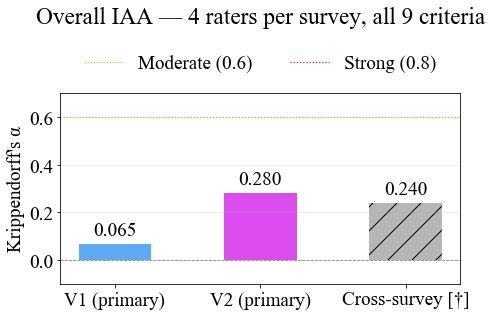

Figure saved → ./Fig/IAA_overall_alpha.{pdf,png}


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Summary table ─────────────────────────────────────────────────────────────
df_iaa_summary = pd.DataFrame({
    "Survey":  ["V1 (primary)", "V2 (primary)", "Cross-survey [†]"],
    "Raters":  ["P1–P4", "P5–P8", "P1–P8 (disconnected)"],
    "Design":  ["Connected", "Connected", "Disconnected"],
    "α":       [iaa_results["V1_combined"], iaa_results["V2_combined"], alpha_cross_combined],
}).set_index("Survey")

print("Krippendorff's Alpha (ordinal) — Overall IAA")
print("=" * 55)
print(df_iaa_summary.round(3).to_string())
print()
print("[†] Disconnected design: V1 and V2 raters evaluated different reports.")
print("    D_e estimated from pooled distributions — treat as indicative only.")

# ── Bar chart ─────────────────────────────────────────────────────────────────
FIG_W = 7
fs = paper_fontsizes(FIG_W)
fig, ax = plt.subplots(figsize=(FIG_W, 4.5), facecolor="white")

labels  = df_iaa_summary.index.tolist()
alphas  = df_iaa_summary["α"].values
colors  = ["#429bf4", "#d42cea", "#aaaaaa"]
hatches = ["", "", "/"]

for i, (label, val, color, hatch) in enumerate(zip(labels, alphas, colors, hatches)):
    bar = ax.bar(i, val, color=color, alpha=0.85, hatch=hatch, width=0.5)
    ax.text(i, val + (0.02 if val >= 0 else -0.06), f"{val:.3f}",
            ha="center", va="bottom", fontsize=fs["tick"])

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=fs["tick"])
ax.tick_params(axis="y", labelsize=fs["tick"])
ax.axhline(0,   color="gray",   linestyle="--", linewidth=0.8)
ax.axhline(0.6, color="orange", linestyle=":",  linewidth=1.2, label="Moderate (0.6)")
ax.axhline(0.8, color="red",    linestyle=":",  linewidth=1.2, label="Strong (0.8)")
ax.set_ylabel("Krippendorff's α", fontsize=fs["label"])
ax.set_title("Overall IAA — 4 raters per survey, all 9 criteria", fontsize=fs["title"], pad=fs["title"] * 3)
ax.set_ylim(-0.1, 0.7)
ax.legend(fontsize=fs["legend"], frameon=False, loc="lower center",
          bbox_to_anchor=(0.5, 1.02), ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
savefig_for_paper(fig, "./Fig/IAA_overall_alpha")
plt.show()
print("Figure saved → ./Fig/IAA_overall_alpha.{pdf,png}")

In [11]:
# Structure reminder:
# df_v1_extracted: (4 raters) × (45 items: R1Q1…R5Q9) + token
# Current compute_alpha() lumps all 9 criteria together.
# Per-criterion: for each Qk, select R1Qk…R5Qk → (4 raters × 5 reports per survey)
# Cross-survey:  V1 (4r×5i) + V2 (4r×5i) → (8r×10i) with NaN off-diagonal blocks
print("df_v1_extracted shape:", df_v1_extracted.shape)
print("columns:", df_v1_extracted.columns.tolist())

df_v1_extracted shape: (4, 46)
columns: ['R1Q1', 'R1Q2', 'R1Q3', 'R1Q4', 'R1Q5', 'R1Q6', 'R1Q7', 'R1Q8', 'R1Q9', 'R2Q1', 'R2Q2', 'R2Q3', 'R2Q4', 'R2Q5', 'R2Q6', 'R2Q7', 'R2Q8', 'R2Q9', 'R3Q1', 'R3Q2', 'R3Q3', 'R3Q4', 'R3Q5', 'R3Q6', 'R3Q7', 'R3Q8', 'R3Q9', 'R4Q1', 'R4Q2', 'R4Q3', 'R4Q4', 'R4Q5', 'R4Q6', 'R4Q7', 'R4Q8', 'R4Q9', 'R5Q1', 'R5Q2', 'R5Q3', 'R5Q4', 'R5Q5', 'R5Q6', 'R5Q7', 'R5Q8', 'R5Q9', 'token']


### Per-Criterion IAA Analysis

Same α, computed **separately per criterion** Qk (5 reports per survey; 8 raters × 10 reports cross-survey, missing data handled) instead of lumping all 9 criteria together. Shows which dimensions are objectively agreeable vs. inherently subjective.

In [12]:
criteria_labels = {
    "Q1": "Fluidity",
    "Q2": "Conciseness",
    "Q3": "Relevance",
    "Q4": "Coherence",
    "Q5": "Session Info",
    "Q6": "Affective States",
    "Q7": "Results",
    "Q8": "Cognitive Functions",
    "Q9": "Linguistic Indicators",
}


def select_criterion(df, qk):
    """Select columns for criterion qk (e.g. 'Q1') across all reports, plus drop token."""
    cols = [c for c in df.columns if c.endswith(qk) and c != "token"]
    return df[cols]


def compute_alpha_criterion(df, qk):
    sub = select_criterion(df, qk).values.astype(float)
    try:
        return krippendorff.alpha(reliability_data=sub, level_of_measurement="ordinal")
    except (AssertionError, ValueError):
        # Happens when all raters agree perfectly → domain has only 1 value
        # Perfect agreement → α = 1.0 conceptually, but library can't compute it
        return np.nan


def compute_alpha_criterion_combined(df_v1_group, df_v2_group, qk):
    """Cross-survey alpha for one criterion: V1 and V2 raters see different reports."""
    d1 = select_criterion(df_v1_group, qk).values.astype(float)
    d2 = select_criterion(df_v2_group, qk).values.astype(float)
    nr1, ni1 = d1.shape
    nr2, ni2 = d2.shape
    combined = np.full((nr1 + nr2, ni1 + ni2), np.nan)
    combined[:nr1, :ni1] = d1
    combined[nr1:, ni1:] = d2
    try:
        return krippendorff.alpha(reliability_data=combined, level_of_measurement="ordinal")
    except (AssertionError, ValueError):
        return np.nan


# ── Compute per-criterion alpha for every group ───────────────────────────────
rows = []
for qk, label in criteria_labels.items():
    row = {"Criterion": label}
    for survey_label, df_all, df_ortho, df_student in [
        ("V1", df_v1_extracted, df_ortho_v1, df_student_v1),
        ("V2", df_v2_extracted, df_ortho_v2, df_student_v2),
    ]:
        row[f"{survey_label}_all"]        = compute_alpha_criterion(df_all,     qk)
        row[f"{survey_label}_therapists"] = compute_alpha_criterion(df_ortho,   qk)
        row[f"{survey_label}_students"]   = compute_alpha_criterion(df_student, qk)

    row["Cross_all"]        = compute_alpha_criterion_combined(df_v1_extracted, df_v2_extracted, qk)
    row["Cross_therapists"] = compute_alpha_criterion_combined(df_ortho_v1,     df_ortho_v2,     qk)
    row["Cross_students"]   = compute_alpha_criterion_combined(df_student_v1,   df_student_v2,   qk)
    rows.append(row)

df_per_criterion = pd.DataFrame(rows).set_index("Criterion")
print("Krippendorff's α per criterion (ordinal)\n")
print(df_per_criterion.round(3).to_string())

Krippendorff's α per criterion (ordinal)

                       Cross_all  Cross_students  Cross_therapists  V1_all  V1_students  V1_therapists  V2_all  V2_students  V2_therapists
Criterion                                                                                                                                 
Fluidity                   0.276           0.595             0.139  -0.155       -0.043         -0.340   0.564        1.000          0.718
Conciseness               -0.190           0.128            -0.267  -0.141        0.112            NaN  -0.188       -0.286         -0.800
Relevance                  0.058           0.050            -0.272  -0.092        0.107         -0.590   0.009       -0.292          0.213
Coherence                 -0.157          -0.312            -0.454  -0.230       -0.542         -0.687   0.000       -0.500          0.068
Session Info              -0.160          -0.862             0.083  -0.215       -0.740         -0.471  -0.071       -0.800 

### Rating Distributions per Criterion

The same α can come from very different rating patterns (evenly spread vs. clustered-with-one-outlier). This violin + jittered-point plot shows the raw 1–5 rating distribution per criterion, pooled across surveys and raters, so the α values above can be read alongside how the scale was actually used.

Rating distribution per criterion — n ratings pooled (V1+V2, all raters x reports)
                       count  mean   std
criterion                               
Fluidity                  40  4.08  1.07
Conciseness               40  4.42  0.93
Relevance                 40  3.88  0.99
Coherence                 40  4.05  0.81
Session Info              40  3.55  0.90
Affective States          40  3.65  1.03
Results                   40  4.08  1.19
Cognitive Functions       40  3.48  1.09
Linguistic Indicators     40  3.55  1.41



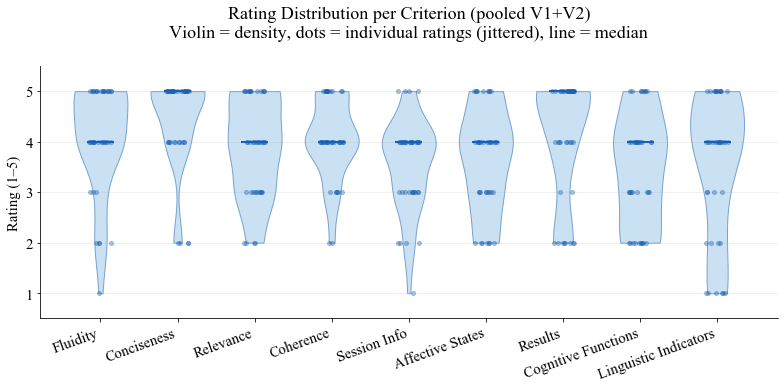

Figure saved → ./Fig/rating_distribution_per_criterion.{pdf,png}  (place as figure* / \textwidth)


In [13]:
# ── Rating distribution per criterion (pooled across V1+V2, all raters) ───────
# Violin (density shape) + jittered raw points + median marker, per criterion.
# Placed as a full-width figure* in LaTeX (9 criteria need the extra width to stay legible).

RATING_VALUES = [1, 2, 3, 4, 5]

def raw_scores_per_criterion(df, qk):
    cols = [c for c in df.columns if c.endswith(qk) and c != "token"]
    vals = df[cols].values.astype(float).ravel()
    return vals[~np.isnan(vals)]

raw_records = []
for survey_label, df in [("V1", df_v1_extracted), ("V2", df_v2_extracted)]:
    for qk, label in criteria_labels.items():
        for v in raw_scores_per_criterion(df, qk):
            raw_records.append({"criterion": label, "score": v})

df_raw = pd.DataFrame(raw_records)
criteria_order = list(criteria_labels.values())
violin_data = [df_raw[df_raw["criterion"] == c]["score"].values for c in criteria_order]

print("Rating distribution per criterion — n ratings pooled (V1+V2, all raters x reports)")
print(df_raw.groupby("criterion")["score"].agg(["count", "mean", "std"]).reindex(criteria_order).round(2).to_string())
print()

FIG_W = 11
fs = paper_fontsizes(FIG_W, placed_width_in=TEXT_WIDTH_IN)
fig3, ax3 = plt.subplots(figsize=(FIG_W, 5.5), facecolor="white")
positions = np.arange(len(criteria_order))

parts = ax3.violinplot(violin_data, positions=positions, widths=0.7,
                        showmeans=False, showmedians=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("#9fc9ea")
    pc.set_edgecolor("#2166ac")
    pc.set_alpha(0.55)
parts["cmedians"].set_color("#1a5fb4")
parts["cmedians"].set_linewidth(2)

np.random.seed(42)
for i, vals in enumerate(violin_data):
    jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
    ax3.scatter(np.full(len(vals), i) + jitter, vals, s=16, color="#1a5fb4", alpha=0.35, zorder=3)

ax3.set_xticks(positions)
ax3.set_xticklabels(criteria_order, rotation=20, ha="right", fontsize=fs["tick"])
ax3.tick_params(axis="y", labelsize=fs["tick"])
ax3.set_ylabel("Rating (1–5)", fontsize=fs["label"])
ax3.set_ylim(0.5, 5.5)
ax3.set_title("Rating Distribution per Criterion (pooled V1+V2)\nViolin = density, dots = individual ratings (jittered), line = median",
              fontsize=fs["title"], pad=fs["title"] * 1.6)
ax3.grid(axis="y", alpha=0.25)
for spine in ["top", "right"]:
    ax3.spines[spine].set_visible(False)

plt.tight_layout()
savefig_for_paper(fig3, "./Fig/rating_distribution_per_criterion")
plt.show()
print("Figure saved → ./Fig/rating_distribution_per_criterion.{pdf,png}  (place as figure* / \\textwidth)")

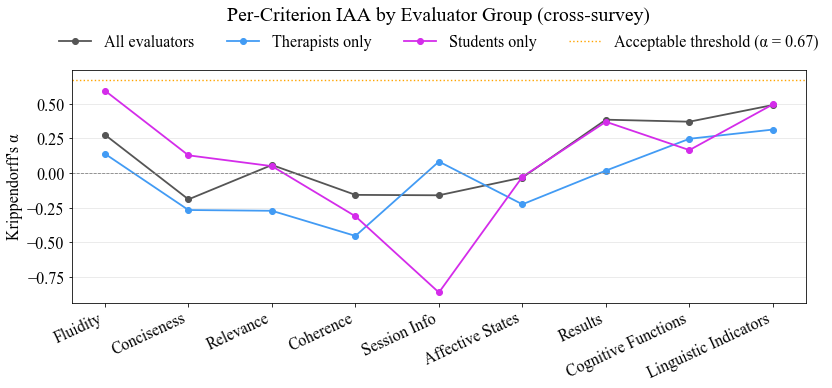

Figure saved → ./Fig/IAA_per_criterion_lineplot.{pdf,png}  (place as figure* / \textwidth)


In [14]:
# ── Line plot: per-criterion alpha for all three groups ───────────────────────
# Placed as a full-width figure* in LaTeX (9 criteria need the extra width to stay legible).
group_cols  = ["Cross_all", "Cross_therapists", "Cross_students"]
group_titles = ["All evaluators", "Therapists only", "Students only"]

FIG_W = 12
fs = paper_fontsizes(FIG_W, placed_width_in=TEXT_WIDTH_IN)
fig2, ax2 = plt.subplots(figsize=(FIG_W, 5.5), facecolor="white")
x = np.arange(len(criteria_labels))
for col, label, color in zip(group_cols, group_titles, ["#555555", "#429bf4", "#d42cea"]):
    ax2.plot(x, df_per_criterion[col].values, marker="o", label=label,
             color=color, linewidth=1.8)

ax2.axhline(0,    color="gray",   linestyle="--", linewidth=0.8)
ax2.axhline(0.67, color="orange", linestyle=":",  linewidth=1.4, label="Acceptable threshold (α = 0.67)")
ax2.set_xticks(x)
ax2.set_xticklabels(criteria_labels.values(), rotation=25, ha="right", fontsize=fs["tick"])
ax2.tick_params(axis="y", labelsize=fs["tick"])
ax2.set_ylabel("Krippendorff's α", fontsize=fs["label"])
ax2.set_title("Per-Criterion IAA by Evaluator Group (cross-survey)", fontsize=fs["title"], pad=fs["title"] * 2.5)
ax2.legend(fontsize=fs["legend"], frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, 1.02), ncol=4)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
savefig_for_paper(fig2, "./Fig/IAA_per_criterion_lineplot")
plt.show()
print("Figure saved → ./Fig/IAA_per_criterion_lineplot.{pdf,png}  (place as figure* / \\textwidth)")

## Therapist vs. Student Scoring Pattern Comparison

Since low agreement is driven by individual variation rather than group membership, the meaningful question is not "do therapists agree more with each other" but "do therapists and students apply different standards?" We compare **per-rater mean score per criterion** (mean over each rater's 5 reports) — n=4 therapists vs. n=4 students.

- **Mann-Whitney U** (two-sided) + **rank-biserial r** as effect size (r > 0 → therapists score higher).
- ⚠️ n=4 per group → minimum achievable p ≈ 0.014; read effect size/direction over p-values.
- Therapists: P1, P4 (V1), P7, P8 (V2). Students: P2, P3 (V1), P5, P6 (V2).
- V1/V2 raters scored different reports, but each survey mixes Template/GPT-4 reports in a similar balance, so rater-level means remain comparable across surveys.

In [15]:
from scipy.stats import mannwhitneyu

THERAPIST_TOKENS = {"therapist_01", "therapist_02", "therapist_03", "therapist_04"}

# ── Build per-rater, per-criterion mean score table (long format) ─────────────
records = []
for survey_label, df in [("V1", df_v1_extracted), ("V2", df_v2_extracted)]:
    for _, row in df.iterrows():
        token = row["token"]
        group = "Therapist" if token in THERAPIST_TOKENS else "Student"
        for qk, label in criteria_labels.items():
            cols = [c for c in df.columns if c.endswith(qk) and c != "token"]
            mean_score = row[cols].mean()
            records.append({
                "survey": survey_label, "rater": token, "group": group,
                "criterion": label, "qk": qk, "mean_score": mean_score,
            })

df_rater_means = pd.DataFrame(records)

# ── Mann-Whitney U + rank-biserial correlation per criterion ──────────────────
stat_rows = []
for label in criteria_labels.values():
    sub = df_rater_means[df_rater_means["criterion"] == label]
    t_scores = sub[sub["group"] == "Therapist"]["mean_score"].values
    s_scores = sub[sub["group"] == "Student"]["mean_score"].values

    U, p = mannwhitneyu(t_scores, s_scores, alternative="two-sided")
    # Standard rank-biserial: positive when therapists (first group) score higher
    r_rb = (2 * U) / (len(t_scores) * len(s_scores)) - 1

    stat_rows.append({
        "Criterion":            label,
        "Therapist (mean±SD)":  f"{t_scores.mean():.2f} ± {t_scores.std():.2f}",
        "Student   (mean±SD)":  f"{s_scores.mean():.2f} ± {s_scores.std():.2f}",
        "Diff (T−S)":           round(t_scores.mean() - s_scores.mean(), 2),
        "U":                    int(U),
        "p":                    round(p, 3),
        "r (rank-biserial)":    round(r_rb, 2),
    })

df_stats = pd.DataFrame(stat_rows).set_index("Criterion")

print("Therapist vs. Student — Per-Criterion Mean Scores (n=4 per group)")
print("=" * 80)
print(df_stats.to_string())
print()
print("r interpretation: positive → therapists scored higher; |r|>0.5 large effect.")
print("p-value: minimum achievable ≈ 0.014 with n=4 per group (perfect rank separation).")


Therapist vs. Student — Per-Criterion Mean Scores (n=4 per group)
                       Diff (T−S) Student   (mean±SD) Therapist (mean±SD)   U      p  r (rank-biserial)
Criterion                                                                                              
Fluidity                    -0.45         4.30 ± 0.17         3.85 ± 0.30   1  0.074              -0.81
Conciseness                  0.65         4.10 ± 0.70         4.75 ± 0.26  12  0.243               0.56
Relevance                    0.25         3.75 ± 0.50         4.00 ± 0.98  11  0.465               0.38
Coherence                   -0.20         4.15 ± 0.43         3.95 ± 0.57   6  0.661              -0.25
Session Info                 0.00         3.55 ± 0.67         3.55 ± 0.79   7  1.000              -0.06
Affective States             0.30         3.50 ± 0.36         3.80 ± 0.71  11  0.384               0.44
Results                     -0.45         4.30 ± 0.30         3.85 ± 0.86   6  0.766              -0.1

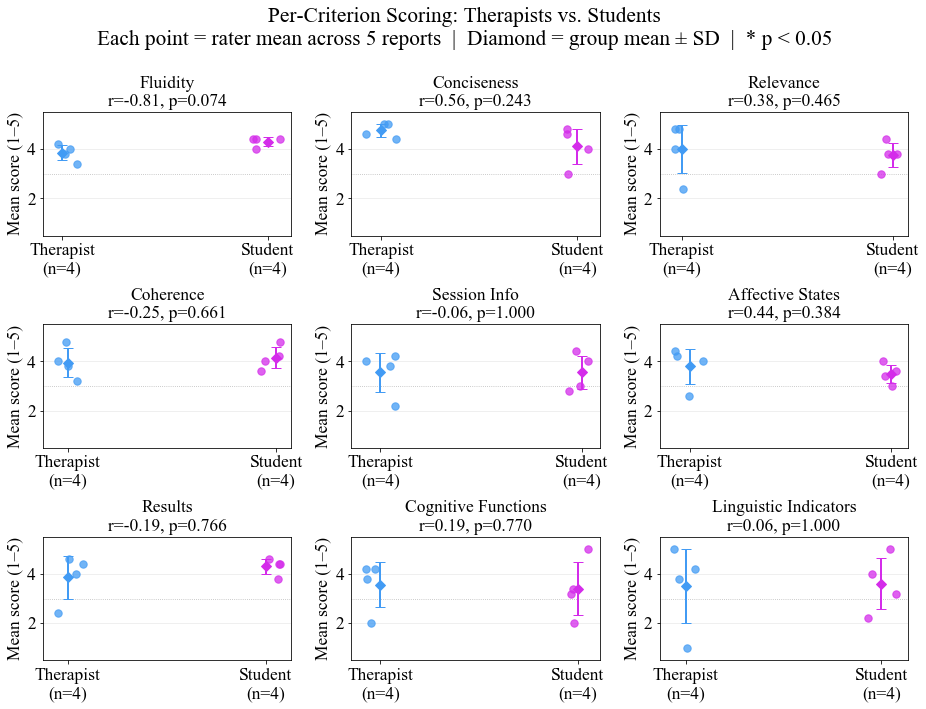

Figure saved → ./Fig/therapist_vs_student_scores.{pdf,png}  (place as figure* / \textwidth)


In [16]:
criteria_list = list(criteria_labels.values())
# Placed as a full-width figure* in LaTeX (3x3 grid needs the extra width to stay legible).
FIG_W = 13
fs = paper_fontsizes(FIG_W, placed_width_in=TEXT_WIDTH_IN)
fig, axes = plt.subplots(3, 3, figsize=(FIG_W, 10), facecolor="white")

GROUP_COLORS = {"Therapist": "#429bf4", "Student": "#d42cea"}
np.random.seed(42)

for ax, criterion in zip(axes.flat, criteria_list):
    for j, group in enumerate(["Therapist", "Student"]):
        scores = df_rater_means[
            (df_rater_means["criterion"] == criterion) &
            (df_rater_means["group"] == group)
        ]["mean_score"].values

        jitter = np.random.uniform(-0.08, 0.08, len(scores))
        ax.scatter([j] * len(scores) + jitter, scores,
                   color=GROUP_COLORS[group], s=55, alpha=0.75, zorder=3)
        ax.errorbar(j, scores.mean(), yerr=scores.std(),
                    fmt="D", color=GROUP_COLORS[group],
                    capsize=5, markersize=7, linewidth=2, zorder=4)

    row = df_stats.loc[criterion]
    sig = "*" if row["p"] < 0.05 else ""
    ax.set_title(f"{criterion}\nr={row['r (rank-biserial)']:.2f}, p={row['p']:.3f}{sig}",
                 fontsize=fs["label"])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Therapist\n(n=4)", "Student\n(n=4)"], fontsize=fs["tick"])
    ax.tick_params(axis="y", labelsize=fs["tick"])
    ax.set_ylim(0.5, 5.5)
    ax.axhline(3, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_ylabel("Mean score (1–5)", fontsize=fs["tick"])
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Per-Criterion Scoring: Therapists vs. Students\n"
    "Each point = rater mean across 5 reports  |  Diamond = group mean ± SD  |  * p < 0.05",
    fontsize=fs["title"],
)
plt.tight_layout(rect=[0, 0, 1, 0.90])
savefig_for_paper(fig, "./Fig/therapist_vs_student_scores")
plt.show()
print("Figure saved → ./Fig/therapist_vs_student_scores.{pdf,png}  (place as figure* / \\textwidth)")

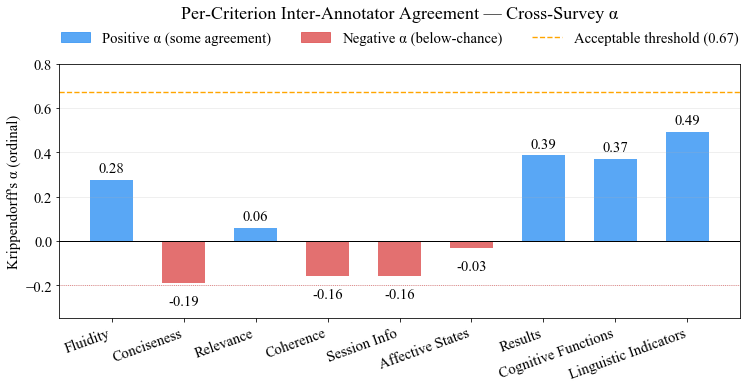

Figure saved → ./Fig/IAA_per_criterion_barchart.{pdf,png}  (place as figure* / \textwidth)


In [17]:
# ── Fig 1: Per-criterion IAA bar chart (cross-survey α, color = positive/negative) ──
# Placed as a full-width figure* in LaTeX (9 criteria need the extra width to stay legible).
cross_alpha = df_per_criterion["Cross_all"].values
criteria_list_labels = list(criteria_labels.values())

bar_colors = ["#429bf4" if v >= 0 else "#e05c5c" for v in cross_alpha]

FIG_W = 11
fs = paper_fontsizes(FIG_W, placed_width_in=TEXT_WIDTH_IN)
fig1, ax1 = plt.subplots(figsize=(FIG_W, 5.5), facecolor="white")
bars = ax1.bar(criteria_list_labels, cross_alpha, color=bar_colors, width=0.6, alpha=0.88)

# value labels on bars
for bar_, val in zip(bars, cross_alpha):
    ypos = val + 0.02 if val >= 0 else val - 0.05
    va   = "bottom" if val >= 0 else "top"
    ax1.text(bar_.get_x() + bar_.get_width() / 2, ypos,
             f"{val:.2f}", ha="center", va=va, fontsize=fs["tick"], fontweight="bold")

# reference lines
ax1.axhline(0,    color="black", linewidth=1.0, linestyle="-")
ax1.axhline(0.67, color="orange", linewidth=1.4, linestyle="--",
            label="Acceptable threshold (α = 0.67)")
ax1.axhline(-0.2, color="#e05c5c", linewidth=0.8, linestyle=":",
            label="Below-chance agreement (α < 0)")

ax1.set_ylabel("Krippendorff's α (ordinal)", fontsize=fs["label"])
ax1.set_title("Per-Criterion Inter-Annotator Agreement — Cross-Survey α", fontsize=fs["title"], pad=fs["title"] * 2.5)
ax1.set_ylim(-0.35, 0.80)
ax1.set_xticklabels(criteria_list_labels, rotation=20, ha="right", fontsize=fs["tick"])
ax1.tick_params(axis="y", labelsize=fs["tick"])
ax1.grid(axis="y", alpha=0.25)

# colour legend patches
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#429bf4", alpha=0.88, label="Positive α (some agreement)"),
    Patch(color="#e05c5c", alpha=0.88, label="Negative α (below-chance)"),
    plt.Line2D([0], [0], color="orange", linewidth=1.4, linestyle="--",
               label="Acceptable threshold (0.67)"),
]
ax1.legend(handles=legend_handles, fontsize=fs["legend"], frameon=False,
           loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3)

plt.tight_layout()
savefig_for_paper(fig1, "./Fig/IAA_per_criterion_barchart")
plt.show()
print("Figure saved → ./Fig/IAA_per_criterion_barchart.{pdf,png}  (place as figure* / \\textwidth)")

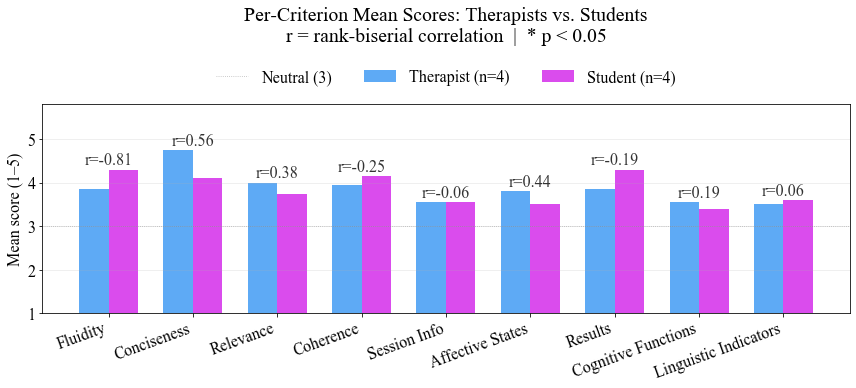

Figure saved → ./Fig/therapist_vs_student_grouped_bar.{pdf,png}  (place as figure* / \textwidth)


In [18]:
# ── Fig 2: Therapist vs Student — grouped bar chart (9 criteria) ──────────────
# Placed as a full-width figure* in LaTeX (9 criteria need the extra width to stay legible).
group_means = (
    df_rater_means.groupby(["criterion", "group"])["mean_score"]
    .mean()
    .unstack("group")
    .reindex(criteria_list_labels)
)

x = np.arange(len(criteria_list_labels))
w = 0.35

FIG_W = 12
fs = paper_fontsizes(FIG_W, placed_width_in=TEXT_WIDTH_IN)
fig2b, ax2b = plt.subplots(figsize=(FIG_W, 5.5), facecolor="white")
b_t = ax2b.bar(x - w / 2, group_means["Therapist"], w,
               label="Therapist (n=4)", color="#429bf4", alpha=0.85)
b_s = ax2b.bar(x + w / 2, group_means["Student"],   w,
               label="Student (n=4)",   color="#d42cea", alpha=0.85)

# annotate effect size r on top
for i, criterion in enumerate(criteria_list_labels):
    r_val = df_stats.loc[criterion, "r (rank-biserial)"]
    p_val = df_stats.loc[criterion, "p"]
    sig   = "*" if p_val < 0.05 else ""
    ymax  = max(group_means.loc[criterion]) + 0.12
    ax2b.text(i, ymax, f"r={r_val:.2f}{sig}", ha="center", fontsize=fs["tick"], color="#333333")

ax2b.set_xticks(x)
ax2b.set_xticklabels(criteria_list_labels, rotation=20, ha="right", fontsize=fs["tick"])
ax2b.tick_params(axis="y", labelsize=fs["tick"])
ax2b.set_ylabel("Mean score (1–5)", fontsize=fs["label"])
ax2b.set_ylim(1, 5.8)
ax2b.axhline(3, color="gray", linestyle=":", linewidth=0.8, alpha=0.6, label="Neutral (3)")
ax2b.set_title("Per-Criterion Mean Scores: Therapists vs. Students\n"
               "r = rank-biserial correlation  |  * p < 0.05", fontsize=fs["title"], pad=fs["title"] * 3.2)
ax2b.legend(fontsize=fs["legend"], frameon=False, loc="lower center",
            bbox_to_anchor=(0.5, 1.02), ncol=3)
ax2b.grid(axis="y", alpha=0.25)

plt.tight_layout()
savefig_for_paper(fig2b, "./Fig/therapist_vs_student_grouped_bar")
plt.show()
print("Figure saved → ./Fig/therapist_vs_student_grouped_bar.{pdf,png}  (place as figure* / \\textwidth)")

In [19]:
# ── Table 1: LaTeX summary table (α + Mann-Whitney per criterion) ─────────────

def fmt_p(p):
    if p < 0.001:
        return r"$<$0.001"
    elif p < 0.05:
        return f"{p:.3f}*"
    else:
        return f"{p:.3f}"

def fmt_r(r):
    """Bold large effects (|r| >= 0.5)."""
    s = f"{r:.2f}"
    return r"\textbf{" + s + "}" if abs(r) >= 0.5 else s

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\caption{Per-criterion inter-annotator agreement (Krippendorff's $\alpha$, ordinal, cross-survey)")
lines.append(r"         and therapist vs.\ student scoring comparison (Mann-Whitney $U$, rank-biserial $r$).")
lines.append(r"         Bold $r$ values indicate large effects ($|r| \geq 0.5$). * $p < 0.05$.}")
lines.append(r"\label{tab:iaa_per_criterion}")
lines.append(r"\begin{tabular}{lc cc c cc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{1}{c}{IAA} & \multicolumn{2}{c}{Mean score (1--5)} & & \multicolumn{2}{c}{Group comparison} \\")
lines.append(r"\cmidrule(lr){2-2} \cmidrule(lr){3-4} \cmidrule(lr){6-7}")
lines.append(r"Criterion & $\alpha$ & Therapist & Student & $\Delta$~(T$-$S) & $r$ & $p$ \\")
lines.append(r"\midrule")

for criterion in criteria_list_labels:
    alpha_val = df_per_criterion.loc[criterion, "Cross_all"]
    row       = df_stats.loc[criterion]
    t_str     = row["Therapist (mean±SD)"].replace("±", r"$\pm$")
    s_str     = row["Student   (mean±SD)"].replace("±", r"$\pm$")
    diff      = row["Diff (T−S)"]
    r_val     = row["r (rank-biserial)"]
    p_val     = row["p"]

    alpha_str = f"{alpha_val:.2f}" if not np.isnan(alpha_val) else "---"
    diff_str  = f"{diff:+.2f}"
    r_str     = fmt_r(r_val)
    p_str     = fmt_p(p_val)

    lines.append(f"  {criterion} & {alpha_str} & {t_str} & {s_str} & {diff_str} & {r_str} & {p_str} \\\\")

lines.append(r"\midrule")
lines.append(r"\multicolumn{7}{l}{\textit{Note.} $\alpha$: Krippendorff's $\alpha$ (cross-survey, disconnected design, indicative only).} \\")
lines.append(r"\multicolumn{7}{l}{$r$: rank-biserial correlation; positive = therapists scored higher.} \\")
lines.append(r"\multicolumn{7}{l}{Min.\ achievable $p \approx 0.014$ with $n=4$ per group (perfect rank separation).} \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\small
\caption{Per-criterion inter-annotator agreement (Krippendorff's $\alpha$, ordinal, cross-survey)
         and therapist vs.\ student scoring comparison (Mann-Whitney $U$, rank-biserial $r$).
         Bold $r$ values indicate large effects ($|r| \geq 0.5$). * $p < 0.05$.}
\label{tab:iaa_per_criterion}
\begin{tabular}{lc cc c cc}
\toprule
 & \multicolumn{1}{c}{IAA} & \multicolumn{2}{c}{Mean score (1--5)} & & \multicolumn{2}{c}{Group comparison} \\
\cmidrule(lr){2-2} \cmidrule(lr){3-4} \cmidrule(lr){6-7}
Criterion & $\alpha$ & Therapist & Student & $\Delta$~(T$-$S) & $r$ & $p$ \\
\midrule
  Fluidity & 0.28 & 3.85 $\pm$ 0.30 & 4.30 $\pm$ 0.17 & -0.45 & \textbf{-0.81} & 0.074 \\
  Conciseness & -0.19 & 4.75 $\pm$ 0.26 & 4.10 $\pm$ 0.70 & +0.65 & \textbf{0.56} & 0.243 \\
  Relevance & 0.06 & 4.00 $\pm$ 0.98 & 3.75 $\pm$ 0.50 & +0.25 & 0.38 & 0.465 \\
  Coherence & -0.16 & 3.95 $\pm$ 0.57 & 4.15 $\pm$ 0.43 & -0.20 & -0.25 & 0.661 \\
  Session Info & -0.16 

## System × Rater-Group Reconciliation

The comparison above pools each rater's mean across all 5 reports, which can mix two different effects since each survey blends Template- and GPT-4-generated reports. Here we split by generation system *before* running the same Mann-Whitney U / rank-biserial r procedure, to see whether a pooled effect is concentrated in one system, holds in both, or cancels out (opposite-sign effects).

In [20]:
# ── System (Template/GPT-4) x Rater-group (Therapist/Student) x Criterion ──
# Builds one long-format table, then derives:
#   View A: mean score by System, within All / Therapists / Students
#   View B: Therapist vs Student comparison, split by System
# using the same per-rater-mean methodology as the pooled comparison above
# (mean_score = row[cols].mean(), n=4 vs n=4).

from scipy.stats import mannwhitneyu

THERAPIST_TOKENS = {"therapist_01", "therapist_02", "therapist_03", "therapist_04"}

# R-slot -> system, per survey.
SYSTEM_BY_SLOT = {
    "V1": {"R1": "Template", "R2": "GPT-4", "R3": "Template", "R4": "GPT-4",  "R5": "Template"},
    "V2": {"R1": "Template", "R2": "GPT-4", "R3": "GPT-4",    "R4": "Template", "R5": "GPT-4"},
}

# ── Raw long-format table (one row per rater x report-slot x criterion) ───────
records = []
for survey_label, df in [("V1", df_v1_extracted), ("V2", df_v2_extracted)]:
    for _, row in df.iterrows():
        token = row["token"]
        rater_group = "Therapist" if token in THERAPIST_TOKENS else "Student"
        for slot, system in SYSTEM_BY_SLOT[survey_label].items():
            for qk, label in criteria_labels.items():
                col = f"{slot}{qk}"
                if col not in df.columns:
                    continue
                records.append({
                    "survey": survey_label, "rater": token, "rater_group": rater_group,
                    "system": system, "slot": slot, "criterion": label, "qk": qk,
                    "score": row[col],
                })

df_full = pd.DataFrame(records)

# ── View A: mean score by System, for All / Therapists / Students ─────────────
view_a_all = (
    df_full.groupby(["criterion", "system"])["score"]
    .agg(["mean", "std"])
    .round(2)
)
print("View A — ALL evaluators, Template vs GPT-4:")
print(view_a_all.to_string())
print()

view_a_therapists = (
    df_full[df_full["rater_group"] == "Therapist"]
    .groupby(["criterion", "system"])["score"]
    .agg(["mean", "std"])
    .round(2)
)
print("View A — THERAPISTS only, Template vs GPT-4:")
print(view_a_therapists.to_string())
print()

view_a_students = (
    df_full[df_full["rater_group"] == "Student"]
    .groupby(["criterion", "system"])["score"]
    .agg(["mean", "std"])
    .round(2)
)
print("View A — STUDENTS only, Template vs GPT-4:")
print(view_a_students.to_string())
print()

# ── Per-rater, per-criterion, per-system mean score ────────────────────────────
rater_system_means = (
    df_full.groupby(["rater", "rater_group", "system", "criterion"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "mean_score"})
)

# ── View B split by system: Mann-Whitney U / rank-biserial r, Therapist vs Student,
#    computed separately within Template and within GPT-4 ─────────────────────
stat_rows = []
for system in ["Template", "GPT-4"]:
    for label in criteria_labels.values():
        sub = rater_system_means[
            (rater_system_means["system"] == system) & (rater_system_means["criterion"] == label)
        ]
        t_scores = sub[sub["rater_group"] == "Therapist"]["mean_score"].values
        s_scores = sub[sub["rater_group"] == "Student"]["mean_score"].values

        U, p = mannwhitneyu(t_scores, s_scores, alternative="two-sided")
        r_rb = (2 * U) / (len(t_scores) * len(s_scores)) - 1

        stat_rows.append({
            "Criterion": label,
            "System": system,
            "Therapist (mean±SD)": f"{t_scores.mean():.2f} ± {t_scores.std():.2f}",
            "Student (mean±SD)":   f"{s_scores.mean():.2f} ± {s_scores.std():.2f}",
            "U": round(U, 1),
            "p": round(p, 3),
            "r (rank-biserial)": round(r_rb, 2),
        })

df_stats_by_system = pd.DataFrame(stat_rows).set_index(["Criterion", "System"])
print("View B split by system — Therapist vs Student, Mann-Whitney U (n=4 vs n=4 per system):")
print(df_stats_by_system.to_string())


View A — ALL evaluators, Template vs GPT-4:
                                mean   std
criterion             system              
Affective States      GPT-4     3.70  1.13
                      Template  3.60  0.94
Cognitive Functions   GPT-4     3.45  1.00
                      Template  3.50  1.19
Coherence             GPT-4     3.85  0.88
                      Template  4.25  0.72
Conciseness           GPT-4     4.70  0.47
                      Template  4.15  1.18
Fluidity              GPT-4     3.65  1.27
                      Template  4.50  0.61
Linguistic Indicators GPT-4     3.85  1.27
                      Template  3.25  1.52
Relevance             GPT-4     3.90  0.97
                      Template  3.85  1.04
Results               GPT-4     3.70  1.30
                      Template  4.45  0.94
Session Info          GPT-4     3.45  1.00
                      Template  3.65  0.81

View A — THERAPISTS only, Template vs GPT-4:
                                mean   std
criteri

## LLM-as-Judge Validation

Five LLM judges (`gpt-4o`, `gpt-4o-mini`, `gpt-6-luna`, `deepseek-flash`, `deepseek-v4-pro`; text-mode, French prompts mirroring the human questionnaire's wording and 1–5 anchors verbatim — see `code/llm_judge/`) scored all 10 reports on the same 9 criteria. Two questions:

1. **Does human IAA predict LLM-human agreement?** The a priori tier classification (Tier 1: α ≥ 0.37; Tier 2: 0 < α < 0.37; Tier 3: α ≤ 0) implies judge-human Pearson r should track human α.
2. **Do judges at least agree with each other?** Higher LLM-LLM than human-human agreement on stylistic dimensions would suggest shared training biases rather than genuine consensus.

Data: `code/llm_judge/output/llm_scores_pointwise.csv` (5 judges × 10 reports × 9 criteria = 450 scored calls, each with a required free-text justification, mirroring the human questionnaire's own comment fields).

In [21]:
# ── Load LLM-judge scores and align with human data already in memory ────────
from scipy.stats import pearsonr

llm_scores_path = "llm_judge/output/llm_scores_pointwise.csv"
df_llm_raw = pd.read_csv(llm_scores_path)

# Exclude "deepseek-chat": DeepSeek's API now silently redirects this model id
# to "deepseek-flash", so data logged under this name may span two different
# underlying models depending on when it was scored (see FINDINGS.md).
df_llm_raw = df_llm_raw[df_llm_raw["model"] != "deepseek-chat"]

JUDGE_MODELS = sorted(df_llm_raw["model"].unique())
print(f"LLM judges in this analysis: {JUDGE_MODELS}")
print(f"Rows: {len(df_llm_raw)} ({len(df_llm_raw) // len(JUDGE_MODELS)} per judge expected)")

# report_id -> mean human score per criterion, using the same slot mapping
# llm_judge/config.yaml encodes (kept in sync with SYSTEM_BY_SLOT above).
REPORT_TO_SLOT = {
    "V1": {"T1": "R1", "G2": "R2", "T3": "R3", "G4": "R4", "T5": "R5"},
    "V2": {"T2": "R1", "G1": "R2", "G3": "R3", "T4": "R4", "G5": "R5"},
}
SLOT_TO_REPORT = {survey: {v: k for k, v in mapping.items()} for survey, mapping in REPORT_TO_SLOT.items()}

human_records = []
for survey_label, df in [("V1", df_v1_extracted), ("V2", df_v2_extracted)]:
    for slot, report_id in SLOT_TO_REPORT[survey_label].items():
        for qk, label in criteria_labels.items():
            col = f"{slot}{qk}"
            if col not in df.columns:
                continue
            for val in df[col].values:
                human_records.append({"report_id": report_id, "criterion": qk, "human_score": val})

df_human_long = pd.DataFrame(human_records)
df_human_mean = df_human_long.groupby(["report_id", "criterion"])["human_score"].mean().reset_index()

df_llm_mean = (
    df_llm_raw.groupby(["model", "report_id", "criterion"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "llm_score"})
)


def safe_pearson(x, y):
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return pearsonr(x, y)[0]


# ── Per-model, per-criterion Pearson r vs. human mean score ───────────────────
corr_rows = []
for model in JUDGE_MODELS:
    m = df_llm_mean[df_llm_mean["model"] == model]
    merged_all = m.merge(df_human_mean, on=["report_id", "criterion"])
    row = {"model": model, "overall": safe_pearson(merged_all["human_score"], merged_all["llm_score"])}
    for qk, label in criteria_labels.items():
        sub = merged_all[merged_all["criterion"] == qk]
        row[label] = safe_pearson(sub["human_score"], sub["llm_score"])
    corr_rows.append(row)

df_llm_human_corr = pd.DataFrame(corr_rows).set_index("model")
print("\nLLM judge vs. human Pearson r, per criterion:")
print(df_llm_human_corr.round(3).to_string())

# ── Cross-judge Krippendorff's alpha (judges-as-raters), overall + per criterion ──
def alpha_across_judges(df_long, item_col, models):
    """df_long: rows with columns [model, <item_col>, score]. Builds a
    (n_models x n_items) reliability matrix and computes ordinal Krippendorff's alpha."""
    items = sorted(df_long[item_col].unique())
    matrix = np.full((len(models), len(items)), np.nan)
    for i, model in enumerate(models):
        s = df_long[df_long["model"] == model].set_index(item_col)["score"]
        for j, item in enumerate(items):
            if item in s.index:
                matrix[i, j] = s.loc[item]
    try:
        return krippendorff.alpha(reliability_data=matrix, level_of_measurement="ordinal")
    except (AssertionError, ValueError):
        return np.nan


llm_alpha_per_criterion = {}
for qk, label in criteria_labels.items():
    sub = df_llm_mean[df_llm_mean["criterion"] == qk].rename(columns={"llm_score": "score"})
    llm_alpha_per_criterion[label] = alpha_across_judges(sub, "report_id", JUDGE_MODELS)

sub_all = df_llm_mean.copy()
sub_all["item"] = sub_all["criterion"] + "::" + sub_all["report_id"]
sub_all = sub_all.rename(columns={"llm_score": "score"})
llm_alpha_overall = alpha_across_judges(sub_all, "item", JUDGE_MODELS)

print(f"\nCross-judge Krippendorff's α (judges as raters, {len(JUDGE_MODELS)} judges):")
print(f"  Overall (9 criteria x 10 reports): {llm_alpha_overall:.3f}")
for label, a in llm_alpha_per_criterion.items():
    print(f"  {label:<22} {a:>7.3f}")

LLM judges in this analysis: ['deepseek-flash', 'deepseek-v4-pro', 'gpt-4o', 'gpt-4o-mini', 'gpt-6-luna']
Rows: 450 (90 per judge expected)

LLM judge vs. human Pearson r, per criterion:
                 Affective States  Cognitive Functions  Coherence  Conciseness  Fluidity  Linguistic Indicators  Relevance  Results  Session Info  overall
model                                                                                                                                                     
deepseek-flash             -0.482                0.006     -0.284       -0.144    -0.420                  0.480      0.356   -0.493           NaN   -0.126
deepseek-v4-pro            -0.565                0.066     -0.089        0.144    -0.853                  0.048     -0.119   -0.258        -0.113   -0.147
gpt-4o                      0.024                0.172     -0.139        0.576       NaN                  0.384      0.097   -0.347           NaN    0.001
gpt-4o-mini                   NaN     

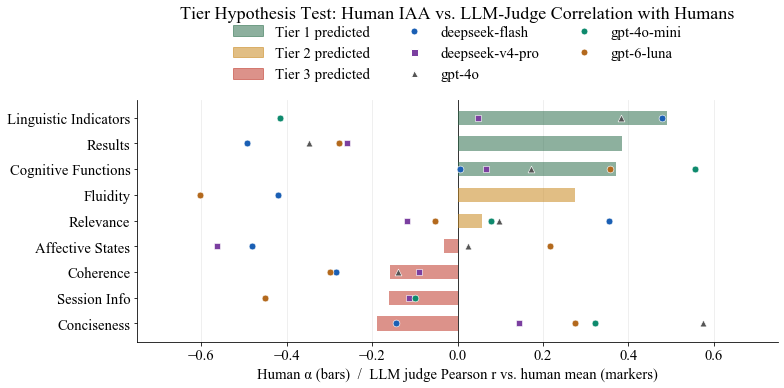

Figure saved → ./Fig/llm_judge_tier_hypothesis.{pdf,png}  (place as figure* / \textwidth)

Criteria where ALL judges' correlation direction/strength matches the predicted tier: 2/9


In [22]:
# ── Fig: Tier hypothesis test — human α vs. LLM-human r per criterion ────────
# Ordered by human Cross-survey α (the tier classification basis). Bars = human
# α, colored by the a priori predicted tier. Markers = each LLM judge's Pearson
# r against the human mean score. If the tier hypothesis held, markers would
# track the bars (high on Tier 1, scattering negative by Tier 3).

TIER_COLORS = {1: "#2f6f4e", 2: "#c98a1f", 3: "#c0392b"}
TIER_OF = {
    "Linguistic Indicators": 1, "Results": 1, "Cognitive Functions": 1,
    "Fluidity": 2, "Relevance": 2,
    "Coherence": 3, "Affective States": 3, "Session Info": 3, "Conciseness": 3,
}

human_alpha_by_criterion = df_per_criterion["Cross_all"]
order = human_alpha_by_criterion.sort_values(ascending=False).index.tolist()

JUDGE_MARKERS = {JUDGE_MODELS[0]: "o", JUDGE_MODELS[1]: "s", JUDGE_MODELS[2]: "^"} if len(JUDGE_MODELS) >= 3 else {}
JUDGE_COLORS = {JUDGE_MODELS[i]: c for i, c in enumerate(["#1a5fb4", "#7b3fa0", "#555555", "#0e8a6d", "#b3691d"][:len(JUDGE_MODELS)])}

FIG_W = 11
fs = paper_fontsizes(FIG_W, placed_width_in=TEXT_WIDTH_IN)
fig4, ax4 = plt.subplots(figsize=(FIG_W, 5.5), facecolor="white")

y = np.arange(len(order))
bar_colors = [TIER_COLORS[TIER_OF[c]] for c in order]
ax4.barh(y, [human_alpha_by_criterion[c] for c in order], height=0.55,
         color=bar_colors, alpha=0.55, zorder=2, label="Human α (Cross-survey)")

for model in JUDGE_MODELS:
    xs = [df_llm_human_corr.loc[model, c] for c in order]
    ax4.scatter(xs, y, marker=JUDGE_MARKERS.get(model, "o"), s=46,
                color=JUDGE_COLORS[model], edgecolor="white", linewidth=0.6,
                zorder=3, label=model)

ax4.axvline(0, color="black", linewidth=0.9, zorder=1)
ax4.set_yticks(y)
ax4.set_yticklabels(order, fontsize=fs["tick"])
ax4.invert_yaxis()
ax4.set_xlim(-0.75, 0.75)
ax4.set_xlabel("Human α (bars)  /  LLM judge Pearson r vs. human mean (markers)", fontsize=fs["label"])
ax4.tick_params(axis="x", labelsize=fs["tick"])
ax4.set_title("Tier Hypothesis Test: Human IAA vs. LLM-Judge Correlation with Humans",
              fontsize=fs["title"], pad=fs["title"] * 4.5)
ax4.grid(axis="x", alpha=0.25)
for spine in ["top", "right"]:
    ax4.spines[spine].set_visible(False)

from matplotlib.patches import Patch
tier_handles = [Patch(color=TIER_COLORS[t], alpha=0.55, label=f"Tier {t} predicted") for t in [1, 2, 3]]
judge_handles = [plt.Line2D([0], [0], marker=JUDGE_MARKERS.get(m, "o"), color="white",
                             markerfacecolor=JUDGE_COLORS[m], markeredgecolor="white",
                             markersize=7, label=m) for m in JUDGE_MODELS]
ax4.legend(handles=tier_handles + judge_handles, fontsize=fs["legend"], frameon=False,
           loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3)

plt.tight_layout()
savefig_for_paper(fig4, "./Fig/llm_judge_tier_hypothesis")
plt.show()
print("Figure saved → ./Fig/llm_judge_tier_hypothesis.{pdf,png}  (place as figure* / \\textwidth)")

n_tiers_correct = sum(
    1 for c in order
    if (TIER_OF[c] == 1 and all(df_llm_human_corr.loc[m, c] > 0.3 for m in JUDGE_MODELS if not np.isnan(df_llm_human_corr.loc[m, c])))
    or (TIER_OF[c] == 3 and all(df_llm_human_corr.loc[m, c] < 0 for m in JUDGE_MODELS if not np.isnan(df_llm_human_corr.loc[m, c])))
)
print(f"\nCriteria where ALL judges' correlation direction/strength matches the predicted tier: {n_tiers_correct}/9")

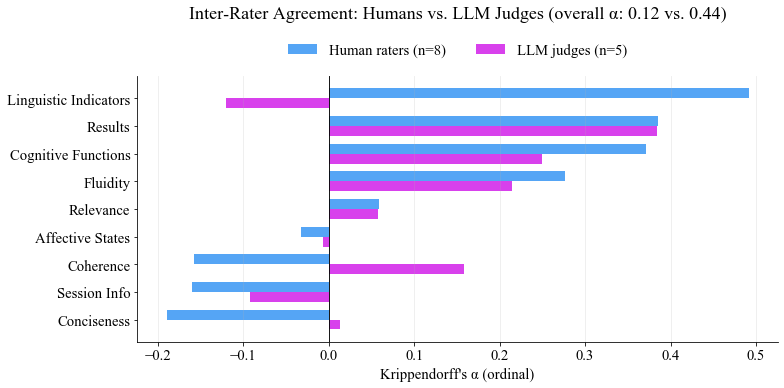

Figure saved → ./Fig/llm_judge_cross_judge_iaa.{pdf,png}  (place as figure* / \textwidth)

Overall: human α = 0.116 (mean across 9 criteria), LLM-judge α = 0.439 (pooled 9x10 matrix, 5 judges).
LLM judges agree with EACH OTHER more than humans do overall (α 0.44 vs 0.12) — but this convergence is uneven and does not track the same criteria humans agree on: LLM α is negative on 3/9 criteria (vs. 4/9 for humans), including Linguistic Indicators, the criterion with the HIGHEST human agreement (α=0.49) — judges disagree with each other most on exactly the dimension humans agree on most. This pattern (elevated but criterion-inconsistent LLM-LLM agreement) is more consistent with judges sharing surface-level heuristics on some criteria than with genuine convergence on a shared underlying construct.


In [23]:
# ── Fig: Cross-judge IAA vs. human IAA — do LLM judges converge with each other? ──
# Grouped horizontal bars, same criterion order as the tier figure above, so the
# two figures read together. If LLM judges shared a common bias, their α would
# be visibly higher than the humans' on the same (stylistic) criteria.

FIG_W = 11
fs = paper_fontsizes(FIG_W, placed_width_in=TEXT_WIDTH_IN)
fig5, ax5 = plt.subplots(figsize=(FIG_W, 5.5), facecolor="white")

y = np.arange(len(order))
h = 0.36
human_vals = [human_alpha_by_criterion[c] for c in order]
llm_vals = [llm_alpha_per_criterion[c] for c in order]

ax5.barh(y - h / 2, human_vals, height=h, color="#429bf4", alpha=0.9, label="Human raters (n=8)")
ax5.barh(y + h / 2, llm_vals, height=h, color="#d42cea", alpha=0.9, label=f"LLM judges (n={len(JUDGE_MODELS)})")

ax5.axvline(0, color="black", linewidth=0.9)
ax5.set_yticks(y)
ax5.set_yticklabels(order, fontsize=fs["tick"])
ax5.invert_yaxis()
ax5.set_xlabel("Krippendorff's α (ordinal)", fontsize=fs["label"])
ax5.tick_params(axis="x", labelsize=fs["tick"])
ax5.set_title(f"Inter-Rater Agreement: Humans vs. LLM Judges (overall α: {human_alpha_by_criterion.mean():.2f} vs. {llm_alpha_overall:.2f})",
              fontsize=fs["title"], pad=fs["title"] * 3.2)
ax5.grid(axis="x", alpha=0.25)
for spine in ["top", "right"]:
    ax5.spines[spine].set_visible(False)
ax5.legend(fontsize=fs["legend"], frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.tight_layout()
savefig_for_paper(fig5, "./Fig/llm_judge_cross_judge_iaa")
plt.show()
print("Figure saved → ./Fig/llm_judge_cross_judge_iaa.{pdf,png}  (place as figure* / \\textwidth)")

human_overall_mean = human_alpha_by_criterion.mean()
n_llm_negative = sum(1 for v in llm_alpha_per_criterion.values() if v < 0)
n_human_negative = sum(1 for v in human_vals if v < 0)
print(f"\nOverall: human α = {human_overall_mean:.3f} (mean across 9 criteria), "
      f"LLM-judge α = {llm_alpha_overall:.3f} (pooled 9x10 matrix, {len(JUDGE_MODELS)} judges).")
if llm_alpha_overall > human_overall_mean:
    print(f"LLM judges agree with EACH OTHER more than humans do overall (α {llm_alpha_overall:.2f} vs "
          f"{human_overall_mean:.2f}) — but this convergence is uneven and does not track the same "
          f"criteria humans agree on: LLM α is negative on {n_llm_negative}/9 criteria "
          f"(vs. {n_human_negative}/9 for humans), including Linguistic Indicators, the criterion with "
          f"the HIGHEST human agreement (α=0.49) — judges disagree with each other most on exactly the "
          f"dimension humans agree on most. This pattern (elevated but criterion-inconsistent LLM-LLM "
          f"agreement) is more consistent with judges sharing surface-level heuristics on some "
          f"criteria than with genuine convergence on a shared underlying construct.")
else:
    print("No evidence of LLM judges converging with each other more than humans do — "
          "both hover in the same weak range.")